In [4]:
from langgraph.graph import StateGraph, START, END 
from typing import TypedDict


In [16]:
class BatsmanState(TypedDict):
    runs : int
    fours : int
    sixes : int 
    balls : int
    sr : float
    bpb : float
    boundary_percentage : float
    summary : str 

In [30]:
def strike_rate(state: BatsmanState):
    sr = (state['runs']/state['balls']) * 100
    return {'sr': sr}

In [31]:
def boundary_percentage(state: BatsmanState):
    boundary_percentage = ((state['fours'] * 4 + state['sixes'] * 6 ) / state['runs']) * 100 
    

    return {'boundary_percentage':boundary_percentage}

In [41]:
def summary(state: BatsmanState):
    summary = f""" 
    Strikerate : {state['sr']} \n
    balls per boundary : {state['bpb']} \n
    boundary percentage : {state['boundary_percentage']}...
    """

    return {'summary':summary}



In [42]:
def balls_per_boundary(state: BatsmanState) -> BatsmanState:
    bpb = state['balls']/(state['fours']+state['sixes'])
    state['bpb'] = bpb
    return state 

In [43]:
graph = StateGraph(BatsmanState)

In [44]:

graph.add_node("strike_rate", strike_rate)
graph.add_node("boundary_percentage",boundary_percentage)
graph.add_node("balls_per_boundary",balls_per_boundary)
graph.add_node("summary", summary)

In [45]:
# define edges 

graph.add_edge(START,'strike_rate')
graph.add_edge(START,'boundary_percentage')
graph.add_edge(START, 'balls_per_boundary')
graph.add_edge('strike_rate','summary')
graph.add_edge('boundary_percentage','summary')
graph.add_edge('balls_per_boundary','summary')
graph.add_edge('summary', END)


In [46]:
workflow = graph.compile()

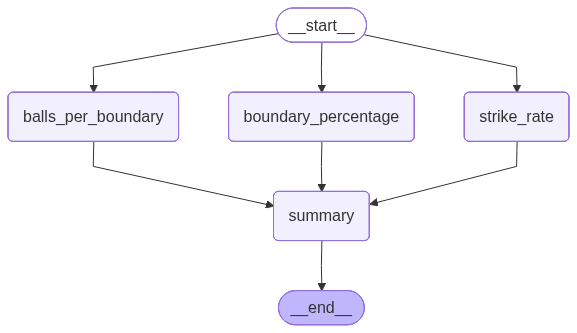

In [47]:
workflow

In [48]:
initial_state = {'runs':100,'balls':50,'fours':10,'sixes':4}
final_state = workflow.invoke(initial_state)

In [49]:
final_state

{'runs': 100,
 'fours': 10,
 'sixes': 4,
 'balls': 50,
 'sr': 200.0,
 'bpb': 3.5714285714285716,
 'boundary_percentage': 64.0,
 'summary': ' \n    Strikerate : 200.0 \n\n    balls per boundary : 3.5714285714285716 \n\n    boundary percentage : 64.0...\n    '}